In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [3]:
xgb_df = pd.read_csv("../XGBoost-Model/Model_data/worlds_xgb_dataset.csv")

xgb_df.head()

,winrate_diff,gold15_diff,xp15_diff,cs15_diff,dragon_diff,baron_diff,tower_diff,target
0,-1.000000,0.0,0.0,0.0,-3.000000,-1.000000,-6.000000,0
1,-1.000000,0.0,0.0,0.0,-1.500000,-1.000000,-8.000000,0
2,-1.000000,0.0,0.0,0.0,-1.000000,-1.000000,-5.000000,1
3,0.000000,0.0,0.0,0.0,0.000000,0.500000,1.000000,1
4,-0.333333,0.0,0.0,0.0,-1.333333,-0.666667,-2.333333,0


In [4]:
X = xgb_df.drop(columns=["target"])

y = xgb_df["target"]


print(X.shape)
print(y.shape)

(9764, 7)
(9764,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7811, 7)
(1953, 7)


In [6]:
model = XGBClassifier(
    objective="binary:logistic",

    n_estimators=300,

    learning_rate=0.05,

    max_depth=4,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

In [7]:
model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
pred = model.predict(X_test)

proba = model.predict_proba(X_test)[:,1]

In [9]:
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC AUC  :", roc_auc_score(y_test, proba))

Accuracy : 0.6395289298515104
Precision: 0.6416131989000916
Recall   : 0.6910167818361304
F1 Score : 0.6653992395437263
ROC AUC  : 0.6735575812312281


In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred
)

cm

array([[549, 391],
       [313, 700]])

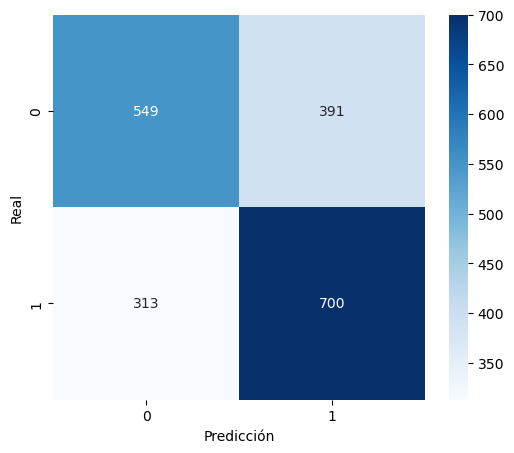

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

In [12]:
print(classification_report(
    y_test,
    pred
))

              precision    recall  f1-score   support

           0       0.64      0.58      0.61       940
           1       0.64      0.69      0.67      1013

    accuracy                           0.64      1953
   macro avg       0.64      0.64      0.64      1953
weighted avg       0.64      0.64      0.64      1953



In [13]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

        Feature  Importance
0  winrate_diff    0.241549
6    tower_diff    0.180822
3     cs15_diff    0.154516
1   gold15_diff    0.114193
4   dragon_diff    0.107467
2     xp15_diff    0.101902
5    baron_diff    0.099552


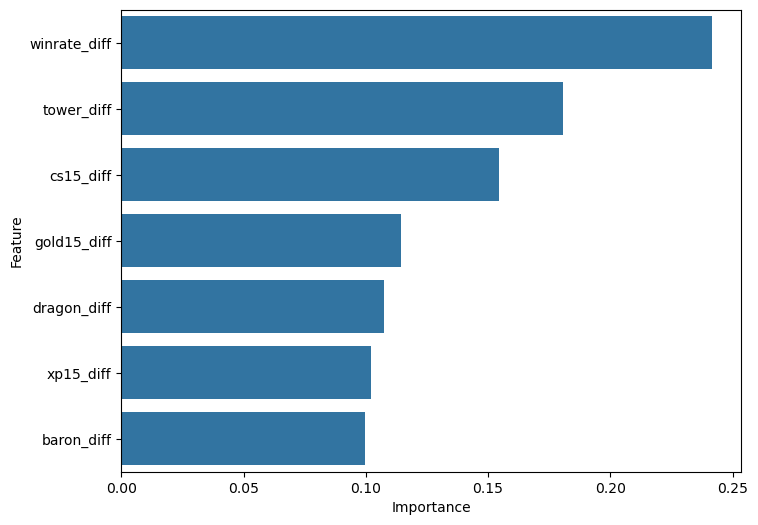

In [14]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.show()

In [15]:
proba = model.predict_proba(X_test)

proba[:10]

array([[0.5100962 , 0.4899038 ],
       [0.62598103, 0.37401897],
       [0.6270077 , 0.37299228],
       [0.52086216, 0.47913784],
       [0.54237545, 0.45762458],
       [0.794726  , 0.20527397],
       [0.490749  , 0.509251  ],
       [0.33041286, 0.66958714],
       [0.52235377, 0.4776462 ],
       [0.6326482 , 0.36735174]], dtype=float32)

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=30,
    n_jobs=-1
)

In [17]:
rf_model.fit(
    X_train,
    y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
pred = rf_model.predict(X_test)

proba = rf_model.predict_proba(X_test)[:,1]

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC AUC  :", roc_auc_score(y_test, proba))

Accuracy : 0.6333845366103431
Precision: 0.6346328195829556
Recall   : 0.6910167818361304
F1 Score : 0.6616257088846881
ROC AUC  : 0.6834996114343324


In [20]:
print(confusion_matrix(y_test, pred))

[[537 403]
 [313 700]]


In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
0,winrate_diff,0.210100
6,tower_diff,0.193216
3,cs15_diff,0.150436
1,gold15_diff,0.145063
2,xp15_diff,0.118960
4,dragon_diff,0.097531
5,baron_diff,0.084694


In [22]:
import joblib

joblib.dump(
    model,
    "worlds_xgb_model.pkl"
)

['worlds_xgb_model.pkl']

In [23]:
model = joblib.load(
    "worlds_xgb_model.pkl"
)